In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xclimate as xclim

In [ ]:
time_slice = slice("1950-01", "2014-12")
year_start = time_slice.start[:4]
year_end = time_slice.stop[:4]
variables = [
    "SMP_month_1",
    "SOILLIQ_month_1",
    "SOILWATER_10CM_month_1",
    "BTRANMN_month_1",
    "BTRANMN_day_1",
    
]

# FHIST

In [21]:
grid = xclim.load_fhist_ppe_grid()

fhist = {}
fhist_full = {}
for v in variables:
    print(f"  {v}")
    name = "_".join(v.split("_")[:-2])
    fhist_full[v] = xclim.load_fhist(v, keep_var_only=True)[name].sel(time=time_slice).reindex_like(grid, method="nearest", tolerance=1e-3)
    fhist_full[v] = fhist_full[v].where(grid.LANDFRAC > 0).chunk({'time': -1})

  SMP_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
  SOILLIQ_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
  SOILWATER_10CM_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
  BTRANMN_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


In [34]:
fhist_soilliq = xclim.load_fhist('SOILLIQ_month_1', keep_var_only=False)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


# LENS2 and GOGA2

In [ ]:
grid_lens = xclim.load_cesm2le_grid()
grid_goga = xclim.load_goga2_grid()

lens = {}
goga = {}
for v in variables:
    print(f"  {v}")
    name = "_".join(v.split("_")[:-2])
    freq = "_".join(v.split("_")[-2:])
    lens[v] = xclim.load_cesm2le(name, "lnd", freq, "h*", keep_var_only=True).sel(time=time_slice)[name].reindex_like(grid_lens, method="nearest", tolerance=1e-3)
    lens[v] = lens[v].where(grid_lens.LANDFRAC > 0).chunk({'time': -1, 'lat': -1, 'lon': -1})

    goga[v] = xclim.load_goga2(name, "lnd", freq, "h*", keep_var_only=True).sel(time=time_slice)[name].reindex_like(grid_goga, method="nearest", tolerance=1e-3)
    goga[v] = goga[v].where(grid_goga.LANDFRAC > 0).chunk({'time': -1, 'lat': -1, 'lon': -1})

  SMP_month_1
1001
1021
1041
1061
1081
1101
1121
1141
1161
1181
1231
1 2 3 4 5 6 7 8 9 10 
1251
1 2 3 4 5 6 7 8 9 10 
1281
1 2 3 4 5 6 7 8 9 10 
1301
1 2 3 4 5 6 7 8 9 10 
  SOILLIQ_month_1
1001
1021
1041
1061
1081
1101
1121
1141
1161
1181
1231
1 2 3 4 5 6 7 8 9 10 
1251
1 2 3 4 5 6 7 8 9 10 
1281
1 2 3 4 5 6 7 8 9 10 
1301
1 2 3 4 5 6 7 8 9 10 
  SOILWATER_10CM_month_1
1001
1021
1041
1061
1081
1101
1121
1141
1161
1181
1231
1 2 3 4 5 6 7 8 9 10 
1251
1 2 3 4 5 6 7 8 9 10 
1281
1 2 3 4 5 6 7 8 9 10 
1301
1 2 3 4 5 6 7 8 9 10 
  BTRANMN_month_1
1001
1021
1041
1061
1081
1101
1121
1141
1161
1181
1231
1 2 3 4 5 6 7 8 9 10 
1251
1 2 3 4 5 6 7 8 9 10 
1281
1 2 3 4 5 6 7 8 9 10 
1301
1 2 3 4 5 6 7 8 9 10 


In [57]:
fhist_smp = fhist_full['SMP_month_1'].isel(member=0).sel(levgrnd=slice(0, 9)).mean(dim='levgrnd')
lens_smp = lens['SMP_month_1'].isel(member=0).sel(levgrnd=slice(0, 9)).mean(dim='levgrnd')
goga_smp = goga['SMP_month_1'].isel(member=0).sel(levgrnd=slice(0, 9)).mean(dim='levgrnd')

fhist_sl_1_0 = fhist_full['SOILLIQ_month_1'].isel(member=0).sel(levsoi=slice(0, 9)).sum(dim='levsoi')
lens_sl_1_0 = lens['SOILLIQ_month_1'].isel(member=0).sel(levsoi=slice(0, 9)).sum(dim='levsoi')
goga_sl_1_0 = goga['SOILLIQ_month_1'].isel(member=0).sel(levsoi=slice(0, 9)).sum(dim='levsoi')

fhist_sl_0_10 = fhist_full['SOILWATER_10CM_month_1'].isel(member=0)
lens_sl_0_10 = lens['SOILWATER_10CM_month_1'].isel(member=0)
goga_sl_0_10 = goga['SOILWATER_10CM_month_1'].isel(member=0)

In [78]:
gc = {'lat': 45, 'lon': 110, 'method': 'nearest'}

fhist_smp_gc = fhist_smp.sel(**gc).compute()
fhist_sl_1_0_gc = fhist_sl_1_0.sel(**gc).compute()
fhist_sl_0_10_gc = fhist_sl_0_10.sel(**gc).compute()

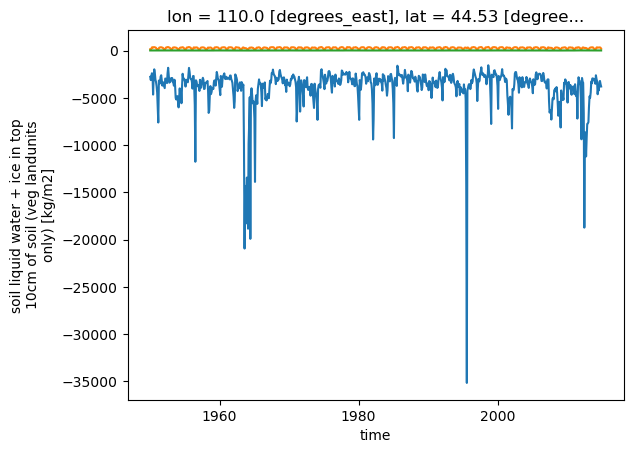

In [83]:
fhist_smp_gc.plot()
fhist_sl_1_0_gc.plot()
fhist_sl_0_10_gc.plot()

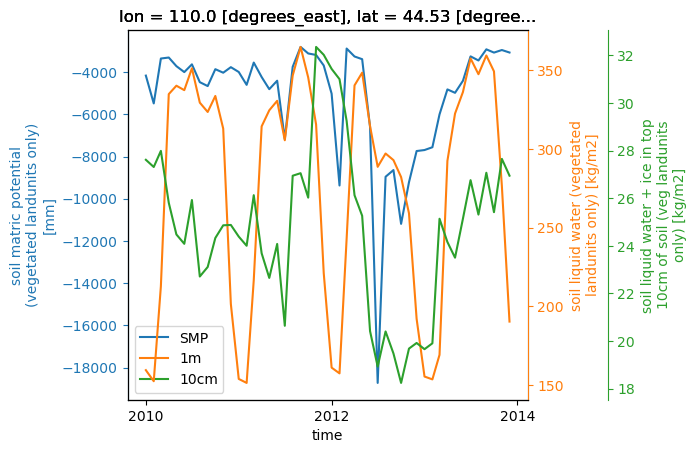

In [86]:
fig, ax = plt.subplots()
fig.subplots_adjust(right=0.75)  # make room for two right axes

ax2 = ax.twinx()
ax3 = ax.twinx()

# Offset ax3 spine to the right
ax3.spines['right'].set_position(('axes', 1.2))

fhist_smp_gc.sel(time=slice('2010-01', '2013-12')).plot(ax=ax, color='tab:blue', label='SMP')
fhist_sl_1_0_gc.sel(time=slice('2010-01', '2013-12')).plot(ax=ax2, color='tab:orange', label='1m')
fhist_sl_0_10_gc.sel(time=slice('2010-01', '2013-12')).plot(ax=ax3, color='tab:green', label='10cm')

ax3.spines['right'].set_visible(True)  # ensure spine is drawn

ax.legend()

handles = (
    ax.get_legend_handles_labels()[0]
    + ax2.get_legend_handles_labels()[0]
    + ax3.get_legend_handles_labels()[0]
)
labels = (
    ax.get_legend_handles_labels()[1]
    + ax2.get_legend_handles_labels()[1]
    + ax3.get_legend_handles_labels()[1]
)

ax.legend(handles, labels)

for axis, color in zip([ax, ax2, ax3], ['tab:blue', 'tab:orange', 'tab:green']):
    axis.spines['right'].set_color(color)
    axis.yaxis.label.set_color(color)
    axis.tick_params(axis='y', colors=color)

ax.spines['left'].set_color('tab:blue')

In [ ]:
fhist_smp.sel(**gc).rolling(time=12, center=True).mean().plot(ax=ax, color='tab:blue', label='SMP')
fhist_sl_1_0.sel(**gc).rolling(time=12, center=True).mean().plot(ax=ax2, color='tab:orange', label='1m')
fhist_sl_0_10.sel(**gc).rolling(time=12, center=True).mean().plot(ax=ax3, color='tab:green', label='10cm')

In [79]:
fhist_smp_gc_nan = fhist_smp_gc[~np.isnan(fhist_smp_gc)]
fhist_sl_1_0_gc_nan = fhist_sl_1_0_gc[~np.isnan(fhist_sl_1_0_gc)]
fhist_sl_0_10_gc_nan = fhist_sl_0_10_gc[~np.isnan(fhist_sl_0_10_gc)]

In [80]:
np.corrcoef(fhist_smp_gc_nan, fhist_sl_1_0_gc_nan)

array([[1.        , 0.22155208],
       [0.22155208, 1.        ]])

In [81]:
np.corrcoef(fhist_smp_gc_nan, fhist_sl_0_10_gc_nan)

array([[1.        , 0.67164009],
       [0.67164009, 1.        ]])

In [82]:
np.corrcoef(fhist_sl_1_0_gc_nan, fhist_sl_0_10_gc_nan)

array([[1.        , 0.00571159],
       [0.00571159, 1.        ]])